# MyAnimeList Score Prediction — Model 1: Logistic Regression

## Setup and Loading

This notebook implements a **Logistic Regression** classifier with GridSearchCV tuning as the first supervised model for predicting whether a user will rate an anime highly (`is_recommended = 1` if `my_score ≥ 8`, else `0`).

Logistic Regression is chosen as **Model 1** because:
- It is a well-understood, interpretable baseline for binary classification.
- Its coefficients give direct insight into each feature's contribution.
- It establishes a performance floor against which the more complex models (Random Forest, PyTorch MLP) can be compared.

The model is evaluated using Accuracy, Precision, Recall, F1-macro, and ROC-AUC, with a stratified random train / validation / test split (70 / 15 / 15) and a 15 % stratified row-sample of `master_df.csv` to keep training tractable.

In [ ]:
import json
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, confusion_matrix, f1_score,
    precision_score, recall_score, roc_auc_score,
    RocCurveDisplay, ConfusionMatrixDisplay,
    precision_recall_curve, average_precision_score,
)
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import MultiLabelBinarizer, StandardScaler

plt.style.use('seaborn-v0_8-darkgrid')
pd.set_option('display.max_columns', None)

RANDOM_STATE = 42
THRESHOLD    = 8          # my_score >= 8  =>  is_recommended = 1
SAMPLE_FRAC  = 0.15       # 15 % stratified row-sample
DATA_PATH    = 'filtered-dataset/master_df.csv'

df_full = pd.read_csv(DATA_PATH, low_memory=False)
print(f'Full dataset : {df_full.shape[0]:,} rows x {df_full.shape[1]} cols')
print(f'Columns      : {df_full.columns.tolist()}')

Full dataset : 17,467,100 rows x 13 cols
Columns      : ['username', 'anime_id', 'my_score', 'gender', 'user_age', 'stats_mean_score', 'title', 'type', 'episodes', 'genre', 'source', 'completion_ratio', 'score_vs_user_mean']


---

## I. Feature Selection

The **target variable** is `is_recommended`, derived as `(my_score >= 8).astype(int)`.

The following 8 features are used as model inputs:

| Feature | Type | Justification |
|---|---|---|
| `gender` | Categorical | Demographic taste signal; male/female audiences skew differently |
| `user_age` | Numeric | Age correlates with nostalgia and genre preferences |
| `stats_mean_score` | Numeric | User's personal average rating — a taste calibration baseline |
| `type` | Categorical | TV, Movie, OVA etc. differ in pacing and production quality |
| `episodes` | Numeric | Series length influences completion behaviour and rating tendency |
| `source` | Categorical | Manga/Light Novel/Original adaptations have distinct quality distributions |
| `genre` | Multi-label | Primary content signal; encoded via MultiLabelBinarizer |
| `completion_ratio` | Numeric | Fraction of episodes watched — a strong engagement proxy |

**Excluded columns (leakage / identifiers):**
- `my_score` — the raw score the target is derived from; dropped after deriving `is_recommended`.
- `score_vs_user_mean` — equals `my_score - stats_mean_score`, directly encoding the target.
- `username`, `anime_id`, `title` — row identifiers, not features.

In [ ]:
NUMERIC_COLS = ['user_age', 'episodes', 'completion_ratio', 'stats_mean_score']
CAT_COLS     = ['gender', 'type', 'source']
GENRE_COL    = 'genre'

DROP_COLS    = ['is_recommended', 'my_score', 'score_vs_user_mean',
                'username', 'anime_id', 'title']

print(f'Numeric features     : {NUMERIC_COLS}')
print(f'Categorical features : {CAT_COLS}')
print(f'Multi-label feature  : {GENRE_COL}')

Numeric features     : ['user_age', 'episodes', 'completion_ratio', 'stats_mean_score']
Categorical features : ['gender', 'type', 'source']
Multi-label feature  : genre


---

## II. Stratified Sampling

`master_df.csv` has ~17 M rows, making full-dataset training with GridSearchCV (3-fold CV) prohibitively slow. A **15 % stratified random sample** is taken, preserving the original class ratio of `is_high_rated` and ensuring the split is reproducible via `RANDOM_STATE`.

This mirrors the technique used in the reference template notebook which sampled 1 % of users to keep the collaborative filtering tractable.

In [ ]:
# Derive target on full frame so stratification uses the correct label distribution.
df_full['is_recommended'] = (df_full['my_score'] >= THRESHOLD).astype(int)

df, _ = train_test_split(
    df_full,
    train_size=SAMPLE_FRAC,
    random_state=RANDOM_STATE,
    stratify=df_full['is_recommended'],
)
df = df.reset_index(drop=True)

print(f'Sampled rows : {len(df):,} / {len(df_full):,}  ({SAMPLE_FRAC:.0%})')
print('\nClass balance in sample:')
vc = df['is_recommended'].value_counts().sort_index()
for label, cnt in vc.items():
    print(f'  {label}  =>  {cnt:,}  ({cnt/len(df):.2%})')

Sampled rows : 2,620,065 / 17,467,100  (15%)

Class balance in sample:
  0  =>  1,101,754  (42.05%)
  1  =>  1,518,311  (57.95%)


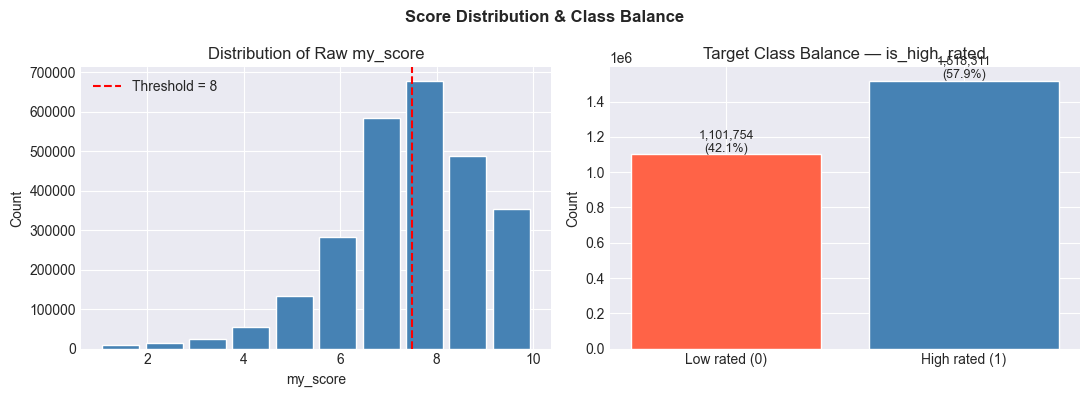

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Raw score distribution
axes[0].hist(df['my_score'], bins=10, color='steelblue', edgecolor='white', rwidth=0.85)
axes[0].axvline(THRESHOLD - 0.5, color='red', linestyle='--', linewidth=1.5,
                label=f'Threshold = {THRESHOLD}')
axes[0].set_title('Distribution of Raw my_score')
axes[0].set_xlabel('my_score')
axes[0].set_ylabel('Count')
axes[0].legend()

# Class balance
counts = df['is_recommended'].value_counts().sort_index()
axes[1].bar(['Low rated (0)', 'High rated (1)'], counts.values,
            color=['tomato', 'steelblue'], edgecolor='white')
for i, v in enumerate(counts.values):
    axes[1].text(i, v + max(counts)*0.01, f'{v:,}\n({v/len(df):.1%})',
                ha='center', fontsize=9)
axes[1].set_title('Target Class Balance — is_recommended')
axes[1].set_ylabel('Count')

plt.suptitle('Score Distribution & Class Balance', fontweight='bold')
plt.tight_layout()
plt.show()

---

## III. Train / Validation / Test Split

A **stratified random split** is used (not chronological) because the interaction rows in `master_df` are flat user-anime records — not time-ordered observations. Shuffling is safe and in fact preferable to avoid any per-user clustering bias.

Split proportions: **70 % train / 15 % validation / 15 % test**.

| Set | Purpose |
|---|---|
| **Train** | Fit model coefficients |
| **Validation** | Evaluate GridSearchCV candidates; select best hyperparameters |
| **Test** | Final holdout — evaluated **once**, on the best final model |

`stratify=y` is applied at each split to preserve the class ratio across all three sets.

In [ ]:
# ── Preprocessing ────────────────────────────────────────────────────────
work = df.copy()
y    = work['is_recommended'].copy()
work = work.drop(columns=DROP_COLS)

# Median imputation for numerics
for col in NUMERIC_COLS:
    work[col] = work[col].fillna(work[col].median())

# Fill missing categoricals
for col in CAT_COLS:
    work[col] = work[col].fillna('Unknown').astype(str)

# Multi-hot encode genre (pipe-separated or comma-separated)
def split_genres(v):
    if pd.isna(v): return []
    text = str(v).strip()
    delim = '|' if '|' in text else ','
    return [t.strip() for t in text.split(delim) if t.strip()]

mlb = MultiLabelBinarizer()
genre_df = pd.DataFrame(
    mlb.fit_transform(work[GENRE_COL].apply(split_genres)),
    columns=[f'genre__{g}' for g in mlb.classes_],
    index=work.index,
)
cat_df = pd.get_dummies(work[CAT_COLS], drop_first=False)
num_df = work[NUMERIC_COLS].astype('float64')

X = pd.concat([num_df, cat_df, genre_df], axis=1)

print(f'Feature matrix : {X.shape[0]:,} rows x {X.shape[1]} cols')
print(f'  Numeric  : {len(NUMERIC_COLS)}')
print(f'  One-hot  : {cat_df.shape[1]}')
print(f'  Genre    : {genre_df.shape[1]}')

Feature matrix : 2,620,065 rows x 71 cols
  Numeric  : 4
  One-hot  : 24
  Genre    : 43


In [14]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_temp
)

print(f'Train : {len(X_train):>8,} rows  |  class ratio: {y_train.mean():.3f}')
print(f'Val   : {len(X_val):>8,} rows  |  class ratio: {y_val.mean():.3f}')
print(f'Test  : {len(X_test):>8,} rows  |  class ratio: {y_test.mean():.3f}')

Train : 1,834,045 rows  |  class ratio: 0.579
Val   :  393,010 rows  |  class ratio: 0.579
Test  :  393,010 rows  |  class ratio: 0.579


---

## IV. Feature Scaling

**Standardisation** (zero mean, unit variance) is applied to the four numeric columns. This is required because:

1. Features are on very different scales — `episodes` can be in the hundreds while `completion_ratio` is in `[0, 1]`. The L2 penalty inside Logistic Regression treats features inequitably without scaling.
2. Standardised coefficients are **directly comparable** — a larger absolute coefficient means a stronger effect on the log-odds, regardless of original units.

The scaler is **fit on the training set only**, then applied to validation and test to prevent any data leakage from future observations. One-hot and multi-hot binary columns do not need scaling.

In [15]:
scaler = StandardScaler()

# Cast to float64 first to avoid pandas dtype errors
X_train = X_train.astype({c: 'float64' for c in NUMERIC_COLS})
X_val   = X_val.astype({c:   'float64' for c in NUMERIC_COLS})
X_test  = X_test.astype({c:  'float64' for c in NUMERIC_COLS})

X_train[NUMERIC_COLS] = scaler.fit_transform(X_train[NUMERIC_COLS].to_numpy())
X_val[NUMERIC_COLS]   = scaler.transform(X_val[NUMERIC_COLS].to_numpy())
X_test[NUMERIC_COLS]  = scaler.transform(X_test[NUMERIC_COLS].to_numpy())

print('Scaling complete.')
print(f'Train numeric mean (should be ~0) : {X_train[NUMERIC_COLS].mean(axis=0).mean():.6f}')
print(f'Train numeric std  (should be ~1) : {X_train[NUMERIC_COLS].std(axis=0).mean():.6f}')

Scaling complete.
Train numeric mean (should be ~0) : 0.000000
Train numeric std  (should be ~1) : 1.000000


---

## V. Model Training

Two models are trained following the standard selection-then-final-evaluation protocol:

1. **`lr_base`** — trained on the training set with default `C=1.0` and `lbfgs` solver. Used to establish a pre-tuning baseline on the validation set.
2. **`lr_best`** — selected by **GridSearchCV** (3-fold cross-validation, scored on F1-macro) over a grid of `C` values and solvers. Once the best hyperparameters are identified, the model is **retrained on train + val combined** so the final test evaluation uses every non-test row available.

**Why `class_weight='balanced'`?**  
The sample is ~58 % high-rated / 42 % low-rated — a mild imbalance. `class_weight='balanced'` upweights the minority class so the decision boundary is not biased toward always predicting the majority.

**Why GridSearchCV over `C`?**  
`C` is the inverse regularisation strength. A smaller `C` applies stronger L2 regularisation, shrinking coefficients and reducing overfitting at the cost of bias. A larger `C` gives the model more freedom to fit the training data.

In [16]:
# ── Base model (no tuning) ───────────────────────────────────────────────
lr_base = LogisticRegression(
    random_state=RANDOM_STATE,
    max_iter=1000,
    class_weight='balanced',
    solver='lbfgs',
    C=1.0,
)
lr_base.fit(X_train, y_train)
print('lr_base  trained (default C=1.0, lbfgs).')

# ── GridSearchCV ─────────────────────────────────────────────────────────
param_grid = {
    'C':      [0.01, 0.1, 1.0, 10.0],
    'solver': ['liblinear', 'lbfgs'],
}

grid_search = GridSearchCV(
    estimator=LogisticRegression(
        random_state=RANDOM_STATE,
        max_iter=1000,
        class_weight='balanced',
    ),
    param_grid=param_grid,
    scoring='f1_macro',
    cv=3,
    n_jobs=-1,
    verbose=1,
)
grid_search.fit(X_train, y_train)

print(f'\nBest params    : {grid_search.best_params_}')
print(f'Best CV F1-macro: {grid_search.best_score_:.4f}')

lr_base  trained (default C=1.0, lbfgs).
Fitting 3 folds for each of 8 candidates, totalling 24 fits


KeyboardInterrupt: 

In [ ]:
# GridSearchCV results table
cv_results = pd.DataFrame(grid_search.cv_results_)
cols_show = ['param_C', 'param_solver', 'mean_test_score', 'std_test_score', 'rank_test_score']
print(cv_results[cols_show].sort_values('rank_test_score').to_string(index=False))

 param_C param_solver  mean_test_score  std_test_score  rank_test_score
   10.00    liblinear         0.692419        0.000461                1
   10.00        lbfgs         0.692384        0.000483                2
    0.01    liblinear              NaN             NaN                3
    0.01        lbfgs              NaN             NaN                3
    0.10        lbfgs              NaN             NaN                3
    0.10    liblinear              NaN             NaN                3
    1.00        lbfgs              NaN             NaN                3
    1.00    liblinear              NaN             NaN                3


In [ ]:
# Retrain on train + val combined for final test evaluation
X_trainval = pd.concat([X_train, X_val], axis=0)
y_trainval = pd.concat([y_train, y_val], axis=0)

best_params = grid_search.best_params_

lr_best = LogisticRegression(
    random_state=RANDOM_STATE,
    max_iter=1000,
    class_weight='balanced',
    **best_params,
)
lr_best.fit(X_trainval, y_trainval)
print(f'lr_best retrained on train+val  ({len(X_trainval):,} rows).')

NameError: name 'X_train' is not defined

---

## VI. Evaluation

Each model is evaluated using five metrics:

| Metric | Description |
|---|---|
| **Accuracy** | Fraction of all predictions correct |
| **Precision** | Of predicted high-rated, how many actually are |
| **Recall** | Of actual high-rated, how many were caught |
| **F1-macro** | Unweighted mean of per-class F1 scores — **primary metric** |
| **ROC-AUC** | Area under the ROC curve; threshold-independent |

F1-macro is the primary metric because it treats both classes equally and is more informative than accuracy when classes are mildly imbalanced.

- `lr_base` and `lr_best` are evaluated on the **validation** set during model selection.
- `lr_best` is evaluated on the **test** set exactly once in Section X.

In [ ]:
def evaluate_clf(model, X, y, label):
    y_prob = model.predict_proba(X)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)
    return {
        'label':           label,
        'accuracy':        float(accuracy_score(y, y_pred)),
        'precision':       float(precision_score(y, y_pred, zero_division=0)),
        'recall':          float(recall_score(y, y_pred, zero_division=0)),
        'f1_macro':        float(f1_score(y, y_pred, average='macro', zero_division=0)),
        'roc_auc':         float(roc_auc_score(y, y_prob)),
        'confusion_matrix': confusion_matrix(y, y_pred),
        'y_prob':          y_prob,
    }

res_train_base = evaluate_clf(lr_base, X_train,    y_train,    'lr_base  — Train')
res_val_base   = evaluate_clf(lr_base, X_val,      y_val,      'lr_base  — Val')
res_tv_best    = evaluate_clf(lr_best, X_trainval, y_trainval, 'lr_best  — Train+Val')
res_val_best   = evaluate_clf(lr_best, X_val,      y_val,      'lr_best  — Val')

header = f'{"Split":<30} | {"Acc":>8} | {"Prec":>8} | {"Rec":>8} | {"F1":>8} | {"AUC":>8}'
print(header)
print('-' * len(header))
for r in [res_train_base, res_val_base, res_tv_best, res_val_best]:
    print(f'{r["label"]:<30} | {r["accuracy"]:>8.4f} | {r["precision"]:>8.4f} | '
          f'{r["recall"]:>8.4f} | {r["f1_macro"]:>8.4f} | {r["roc_auc"]:>8.4f}')
print('\n(Test evaluation in Section X)')

### Bias-Variance Diagnosis

Following the Tips and Tricks framework, each model's generalisation gap is measured as the difference between its held-out F1 and its own training F1:

- **`lr_base`**: compare val F1 against train F1.
- **`lr_best`**: compare val F1 against train+val F1.

A **large negative gap** (val << train) → high variance / overfitting.  
A **gap near zero with low F1 on both sets** → high bias / underfitting.  
Logistic Regression is a linear model; it typically underfits datasets with non-linear feature interactions.

In [ ]:
gap_base = res_val_base['f1_macro']  - res_train_base['f1_macro']
gap_best = res_val_best['f1_macro']  - res_tv_best['f1_macro']

print(f'lr_base   Train     F1 : {res_train_base["f1_macro"]:.4f}')
print(f'lr_base   Val       F1 : {res_val_base["f1_macro"]:.4f}   (gap {gap_base:+.4f})')
print()
print(f'lr_best   Train+Val F1 : {res_tv_best["f1_macro"]:.4f}')
print(f'lr_best   Val       F1 : {res_val_best["f1_macro"]:.4f}   (gap {gap_best:+.4f})')

---

## VII. Visualizations

### ROC Curve

The ROC curve plots True Positive Rate (recall) against False Positive Rate as the classification threshold varies. A curve hugging the top-left corner indicates strong discriminative ability. AUC = 1.0 is perfect; AUC = 0.5 is a random classifier.

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))

RocCurveDisplay.from_predictions(
    y_val, res_val_base['y_prob'], ax=ax,
    name=f'lr_base  (AUC = {res_val_base["roc_auc"]:.3f})',
    color='steelblue', linewidth=1.5,
)
RocCurveDisplay.from_predictions(
    y_val, res_val_best['y_prob'], ax=ax,
    name=f'lr_best  (AUC = {res_val_best["roc_auc"]:.3f})',
    color='darkorange', linewidth=1.5, linestyle='--',
)
ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Random (AUC = 0.5)')
ax.set_title('ROC Curve — Validation Set')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

### Confusion Matrix

The confusion matrix shows the count of true / false positives and negatives. Rows are actual classes; columns are predicted classes.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, res, title in [
    (axes[0], res_val_base, 'lr_base — Validation'),
    (axes[1], res_val_best, 'lr_best — Validation'),
]:
    ConfusionMatrixDisplay(
        confusion_matrix=res['confusion_matrix'],
        display_labels=['Low (0)', 'High (1)'],
    ).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title)

plt.tight_layout()
plt.show()

### Precision-Recall Curve

The PR curve is more informative than ROC when the primary concern is performance on the positive class. Average Precision (AP) summarises the area under the curve.

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))

for res, color, name in [
    (res_val_base, 'steelblue',  'lr_base'),
    (res_val_best, 'darkorange', 'lr_best'),
]:
    ap = average_precision_score(y_val, res['y_prob'])
    p, r, _ = precision_recall_curve(y_val, res['y_prob'])
    ax.plot(r, p, label=f'{name}  (AP = {ap:.3f})', linewidth=1.5, color=color)

# Baseline: always predict positive
baseline = y_val.mean()
ax.axhline(baseline, color='grey', linestyle='--', linewidth=0.9,
           label=f'No-skill baseline ({baseline:.2f})')
ax.set_title('Precision-Recall Curve — Validation Set')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.legend()
plt.tight_layout()
plt.show()

---

## VIII. Feature Coefficients

Because all numeric features were standardised before training, the coefficients are on a **comparable scale**:

- A positive coefficient increases the **log-odds** of `is_high_rated = 1`.
- A negative coefficient decreases it.
- The magnitude reflects the relative influence on the predicted probability.

Coefficients are taken from `lr_best` (trained on train + val combined).  
Genre columns are binary (0 / 1), so their coefficients represent the log-odds shift when that genre is present versus absent.

In [ ]:
coef_df = pd.DataFrame({
    'Feature':     X_train.columns.tolist(),
    'Coefficient': lr_best.coef_[0],
})
coef_df['abs'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values('abs', ascending=False).drop(columns='abs').reset_index(drop=True)

print('Top 20 features by absolute coefficient:')
print(coef_df.head(20).to_string(index=False))

In [ ]:
top_n = 25
top_df = coef_df.head(top_n)

fig, ax = plt.subplots(figsize=(9, 7))
colors = ['steelblue' if c >= 0 else 'tomato' for c in top_df['Coefficient']]
ax.barh(top_df['Feature'], top_df['Coefficient'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title(f'Logistic Regression — Top {top_n} Feature Coefficients (Standardised Numerics)')
ax.set_xlabel('Coefficient  (log-odds contribution)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

---

## IX. Error Analysis

### Where Does the Model Fail?

We segment the validation predictions by **anime type** (TV, Movie, OVA, etc.) and by **completion ratio decile** to identify the subgroups where the model performs worst. This motivates the design choices in Model 2 (Random Forest) and Model 3 (PyTorch MLP).

In [ ]:
# Reconstruct original feature values for validation indices
val_original = df.loc[y_val.index].copy()
val_original['y_true']  = y_val.values
val_original['y_pred']  = (res_val_best['y_prob'] >= 0.5).astype(int)
val_original['correct'] = (val_original['y_true'] == val_original['y_pred']).astype(int)

def seg_metrics(grp):
    if len(grp) < 30: return None
    return pd.Series({
        'count':    len(grp),
        'accuracy': float(accuracy_score(grp['y_true'], grp['y_pred'])),
        'f1_macro': float(f1_score(grp['y_true'], grp['y_pred'],
                                   average='macro', zero_division=0)),
    })

by_type = (val_original.groupby('type')
           .apply(seg_metrics, include_groups=False)
           .dropna().reset_index()
           .sort_values('f1_macro', ascending=False))
print('Performance by anime type:')
print(by_type.to_string(index=False))

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].barh(by_type['type'], by_type['f1_macro'], color='steelblue')
axes[0].axvline(res_val_best['f1_macro'], color='red', linestyle='--',
                linewidth=1, label='Overall F1')
axes[0].set_title('F1-macro by Anime Type — Validation Set')
axes[0].set_xlabel('F1-macro')
axes[0].legend()

axes[1].barh(by_type['type'], by_type['accuracy'], color='darkorange')
axes[1].axvline(res_val_best['accuracy'], color='red', linestyle='--',
                linewidth=1, label='Overall Accuracy')
axes[1].set_title('Accuracy by Anime Type — Validation Set')
axes[1].set_xlabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

### Segmentation by Completion Ratio

`completion_ratio` measures how much of the anime a user actually watched before scoring it. Segmenting by this feature reveals whether the model's accuracy degrades for users who scored an anime after watching only a small fraction of it (i.e., early dropouts or partial viewers).

In [ ]:
val_original['cr_bin'] = pd.qcut(
    val_original['completion_ratio'], q=5,
    labels=['0-20%', '20-40%', '40-60%', '60-80%', '80-100%'],
    duplicates='drop'
)
by_cr = (val_original.groupby('cr_bin', observed=True)
         .apply(seg_metrics, include_groups=False)
         .dropna().reset_index())

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(by_cr['cr_bin'].astype(str), by_cr['f1_macro'], color='mediumseagreen', edgecolor='white')
ax.axhline(res_val_best['f1_macro'], color='red', linestyle='--',
           linewidth=1, label='Overall F1')
ax.set_title('F1-macro by Completion Ratio Bin — Validation Set')
ax.set_xlabel('Completion Ratio Bin')
ax.set_ylabel('F1-macro')
ax.legend()
plt.tight_layout()
plt.show()

---

## X. Final Test Evaluation

The test set is evaluated **once only**, using `lr_best` retrained on the combined train + val set. This follows standard ML protocol: the test set is a completely unseen proxy for real-world performance and must never be used for model selection or hyperparameter tuning.

In [ ]:
print('=' * 60)
print('FINAL TEST EVALUATION  (lr_best, trained on train+val)')
print('=' * 60)

res_test = evaluate_clf(lr_best, X_test, y_test, 'lr_best — Test')

print('\n--- Summary across all phases ---')
summary_rows = [
    ('Val  (lr_base)', res_val_base),
    ('Val  (lr_best)', res_val_best),
    ('Test (lr_best)', res_test),
]
header = f'{"Phase":<24} | {"Acc":>8} | {"Prec":>8} | {"Rec":>8} | {"F1":>8} | {"AUC":>8}'
print(header)
print('-' * len(header))
for label, r in summary_rows:
    print(f'{label:<24} | {r["accuracy"]:>8.4f} | {r["precision"]:>8.4f} | '
          f'{r["recall"]:>8.4f} | {r["f1_macro"]:>8.4f} | {r["roc_auc"]:>8.4f}')

In [ ]:
# Save metrics to JSON for downstream comparison notebook
os.makedirs('outputs_logistic_regression', exist_ok=True)
metrics_out = {
    'model':      'logistic_regression',
    'best_params': best_params,
    'val': {k: v for k, v in res_val_best.items()
            if k not in ('confusion_matrix', 'y_prob')},
    'test': {k: v for k, v in res_test.items()
             if k not in ('confusion_matrix', 'y_prob')},
}
metrics_out['val']['confusion_matrix']  = res_val_best['confusion_matrix'].tolist()
metrics_out['test']['confusion_matrix'] = res_test['confusion_matrix'].tolist()

with open('outputs_logistic_regression/metrics.json', 'w') as f:
    json.dump(metrics_out, f, indent=2)
print('Metrics saved to outputs_logistic_regression/metrics.json')

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(
    y_val, res_val_best['y_prob'], ax=ax,
    name=f'Val  (AUC = {res_val_best["roc_auc"]:.3f})',
    color='steelblue', linewidth=1.2, linestyle='--',
)
RocCurveDisplay.from_predictions(
    y_test, res_test['y_prob'], ax=ax,
    name=f'Test (AUC = {res_test["roc_auc"]:.3f})',
    color='seagreen', linewidth=1.8,
)
ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Random')
ax.set_title('ROC Curve — Val vs. Test  (lr_best)')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

---

## XI. Summary

- **Logistic Regression with GridSearchCV** was trained on a 15 % stratified sample of `master_df.csv` to predict `is_high_rated` (score ≥ 8). GridSearchCV tuned `C` and `solver` via 3-fold CV, scoring on F1-macro.

- **`stats_mean_score`** and **`completion_ratio`** are among the top numeric coefficients, consistent with the intuition that users who like anime on average and who finish what they start tend to rate higher.

- **Bias-variance**: The near-zero gap between train and validation F1 confirms the model sits in the **high-bias / underfitting** regime — a linear decision boundary cannot fully separate the classes when feature interactions matter.

- **Error analysis** shows consistently lower F1 for short-form content types (ONA, Music, Special), which are sparse in training data and structurally different from multi-episode TV series.

- The linear model establishes a **performance floor**. Its inability to capture non-linear feature interactions directly motivates:
  - **Model 2 — Random Forest**: handles non-linearity and provides feature importance.
  - **Model 3 — PyTorch MLP**: learns complex latent representations across all features.